# **Analyse risque crédit**

## **Librairies**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sc
from src.data_quality import *
from src.data_analyse import *
from src.data_transformation import *
from src.data_visualisation import *
from src.feature_engineering import *
from src.modelisation import *

***
# **Import des données**
***

In [ ]:
df_loans = pd.read_csv(r"data\raw\loan_portfolio.csv")
print(f"Dimensions du df : {df_loans.shape[0]} lignes et {df_loans.shape[1]} colonnes")
df_loans.head(10)

***
# **Qualité de la donnée**
***

In [ ]:
dq = DataQuality() # Initialiser la class DataQuality

# Check le type des colonnes
dq.check_types(df_loans)

In [ ]:
dq.check_nulls(df_loans) # Check le nombre et % de valeurs nulles

Les colonnes "loss_given_default", "recovery_rate" et "default_date" ont des valeurs manquantes étant donné que ces colonnes sont uniquement calculées pour les crédit comme étant en défaut. Elles ne seront donc pas utilisées pour la prédiction d'un défaut mais seront utiliser pour l'analyse descriptive du jeu de données.

In [ ]:
# Check si des lignes entière sont dupliquées
dq.check_unique_values(df_loans)

In [ ]:
# Check si des crédits sont dupliqués
dq.check_unique_values(df_loans, cols = ['loan_id'])

In [ ]:
date_cols = dq.check_date_format(df_loans)

In [ ]:
# Vérifier que credit_score soit compris entre 300 et 850
# Vérifier que maturity_months soit compris entre 12 et 120
print(f"Nombre de crédit score compris entre 300 et 850 = {df_loans['credit_score'].between(300, 850).sum()}/{len(df_loans['credit_score'])}")
print(f"Nombre de mois de maturité du crédit compris entre 12 et 120 = {df_loans['maturity_months'].between(12, 120).sum()}/{len(df_loans['maturity_months'])}")

In [ ]:
outliers = dq.check_outliers(df_loans, col_to_ignore=['defaulted', 'credit_score', 'maturity_months'])
outliers

***
# **Transformation des données pour analyse**
***

In [ ]:
dt = DataTransformation()
# Transformation des données de temps
df_loans['origination_date'] = dt.set_datetime_type(df_loans['origination_date'])
df_loans['maturity_date'] = dt.set_datetime_type(df_loans['maturity_date'])
df_loans['default_date'] = dt.set_datetime_type(df_loans['default_date'])

display(df_loans[['origination_date', 'maturity_date', 'default_date']].head(10))

In [ ]:
# On s'assure que la transformation en date a bien eu lieu
dq.check_types(df_loans[['origination_date', 'maturity_date', 'default_date']])

***
# **Analyse descriptive des données**
***

In [ ]:
da = DataAnalyse()
dv = DataVisualisation()

## **Analyse des variables numériques**

### Statistiques

In [ ]:
df_stats_num = da.analyse_var_numeriques(df_loans)
df_stats_num

### Visualisation

In [ ]:
# Histogrammes
fig, axes = plt.subplots(4, 3, figsize=(18, 25))
dv.plot_histogram(df_loans, columns=['credit_score', 'ead', 'coupon_rate', 'leverage', 'interest_coverage', 
                                     'debt_to_equity', 'pd_annual', 'lgd', 'el', 'unexpected_loss', 'rwa',
                                     'recovery_rate'], axes=axes)

In [ ]:
# Boxplot
fig, axes = plt.subplots(4, 3, figsize=(18, 25))
dv.plot_boxplot(df_loans, columns=['credit_score', 'ead', 'coupon_rate', 'leverage', 'interest_coverage', 
                                     'debt_to_equity', 'pd_annual', 'lgd', 'el', 'unexpected_loss', 'rwa',
                                     'recovery_rate'], ax=axes)

## **Analyse des variables catégorielles**

### Statistiques

In [ ]:
da.analyse_var_categorielles(df_loans, col_to_ignore=['loan_id'])

### Visualisation

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
dv.plot_pie(df_loans, columns=['sector', 'loan_type', 'collateral', 'initial_rating'], axes=axes)

In [ ]:
# Variable d'intérêt 'defaulted' (y, ce que l'on va prédire)
default_credit = dt.col_mapping(
    df_loans[['defaulted']], 
    col_to_map='defaulted', 
    new_col_name='défaut de crédit', 
    mapper={0 : 'Non défaut', 1 : 'Défaut'})
dv.plot_pie(default_credit, columns=['défaut de crédit'])

## **Analyse des variables temporelles**

In [ ]:
da.analyse_var_temporelles(df_loans)

## **Analyse des crédits en défaut**

In [ ]:
# Analyse des crédits en défaut
df_default_loans = df_loans[df_loans['defaulted'] == 1]
print(f'Nombre de défaut : {df_default_loans.shape[0]} lignes')
df_default_loans.head(10)

In [ ]:
da.analyse_var_numeriques(df_default_loans)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
dv.plot_pie(df_default_loans, columns=['sector', 'loan_type', 'collateral', 'initial_rating'], axes=axes)

## **Analyse multivariée**

In [ ]:
rating_credit_score = da.groupby_data(
    df_loans, 
    col_x=['initial_rating'], 
    col_y='credit_score', 
    operation=['mean'])\
        .round()\
        .sort_values(by=['mean'], ascending=False)

print("Crédit score moyen par score initial")
display(rating_credit_score)

fig, axes = plt.subplots(1, 1, figsize=(5, 3))
dv.plot_bar(rating_credit_score, x_column='initial_rating', y_columns=['mean'], axes=axes)

***
# **Analyse des liens entre les variables**
***

In [ ]:
df_corr = df_loans.corr(method='pearson', numeric_only=True).round(2)
df_corr

In [ ]:
dv.plot_heatmap(df_corr)

In [ ]:
df_chi2 = da.calcul_khi2(df=df_loans)
df_chi2

***
# **Feature engineering**
***

Préparation des données à la modélisation prédictive (encoding des variables qualitatives, quantitatives)

In [2]:
fe = FeatureEncoding()

## Version 1

Variables explicatives :
- maturity_months
- sector (transformé en dummies)
- loan_type (transformé en dummies)
- collateral (transformé en dummies)
- initial_rating (transformé en dummies)
- credit_score
- ead
- coupon_rate
- leverage
- interest_coverage
- debt_to_equity
- lgd

Variable à expliquée :
- defaulted (variable à expliquée)

In [ ]:
# Première version du df processed
df_processed_v1 = df_loans.drop(columns=['loan_id',             # Aucune importance pour la prédiction
                                         'default_date',        # Conditionné sur les defaulted = 1
                                         'recovery_rate',       # Conditionné sur les defaulted = 1
                                         'loss_given_default',  # Conditionné sur les defaulted = 1
                                         'origination_date',    # date de début brut inutile pour la prédiction
                                         'maturity_date',       # date de fin brut inutile pour la prédiction
                                         'survival_months',     # nombre de mois de survie du crédit (redondant avec maturity_months)
                                         'el',                  # Combinaison linéaire de PD * LGD * EAD
                                         'unexpected_loss',     # Combinaison linéaire de sqrt(PD(1−PD)) × LGD × EAD
                                         'rwa',                 # dérivé du framework réglementaire basé sur : PD LGD EAD maturité
                                         'pd_annual'            # Test sans la probabilité de défaut
                                         ])      

In [ ]:
df_processed_v1.columns

In [ ]:
# Encodage des variables qualitatives en variables muettes (0,1 pour chaque valeur de chaque variable)
df_processed_v1 = fe.one_hot_encoding(df_processed_v1, col=['sector', 'loan_type', 'collateral', 'initial_rating'])
print(f"Encodage des variables qualitatives en variables muettes :\n{df_processed_v1.head(5)}")

In [ ]:
df_processed_v1.to_csv(
    r"data\processed\df_processed_v1.csv", 
    sep=';', 
    encoding='utf-8', 
    header=True, 
    index=False)

***
# **Benchmarking de modèles et de méthodes d'engineering des données**
*** 

In [3]:
models = Models()
metrics = Metrics()
spliter = SplitData()

In [4]:
df_v1 = pd.read_csv(r"data\processed\df_processed_v1.csv", sep=';')
df_v1.head()

,maturity_months,credit_score,ead,coupon_rate,leverage,interest_coverage,debt_to_equity,lgd,defaulted,sector_Consumer,...,collateral_partially_secured,collateral_secured,collateral_unsecured,initial_rating_A,initial_rating_AA,initial_rating_AAA,initial_rating_B,initial_rating_BB,initial_rating_BBB,initial_rating_CCC
0,24,704,1035611.99,3.776,6.54,3.47,1.40,0.7858,0,0,...,0,1,0,0,0,0,1,0,0,0
1,48,702,800786.92,3.895,12.26,4.47,2.77,0.7034,0,0,...,0,0,1,1,0,0,0,0,0,0
2,36,699,4327864.12,4.365,8.98,6.02,2.18,0.5503,0,0,...,0,1,0,0,0,0,0,0,1,0
3,120,641,3810461.19,3.749,13.12,5.93,1.75,0.3541,0,0,...,0,1,0,0,0,0,1,0,0,0
4,48,597,2925538.53,5.231,1.80,4.39,1.79,0.6576,0,0,...,0,0,1,0,0,0,0,0,0,1


In [17]:
X = df_v1.drop(columns=["defaulted"])
y = df_v1["defaulted"]
X_train, X_test, y_train, y_test = spliter.split_in_train_test_stratify(X = X, y = y)

X_train_scaled = fe.standard_scaler(X_train)
X_test_scaled = fe.standard_scaler(X_test)

print(X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape)

(40000, 33) (10000, 33) (40000,) (10000,)


In [18]:
log_reg = models.regression_logistique(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",100
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

In [19]:
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:,1]


MODEL : Régression Logistique
Accuracy : 0.8722
Precision: 0.6628
Recall   : 0.1640
F1-score : 0.2630
ROC-AUC  : 0.7725

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.99      0.93      8610
           1       0.66      0.16      0.26      1390

    accuracy                           0.87     10000
   macro avg       0.77      0.58      0.60     10000
weighted avg       0.85      0.87      0.84     10000



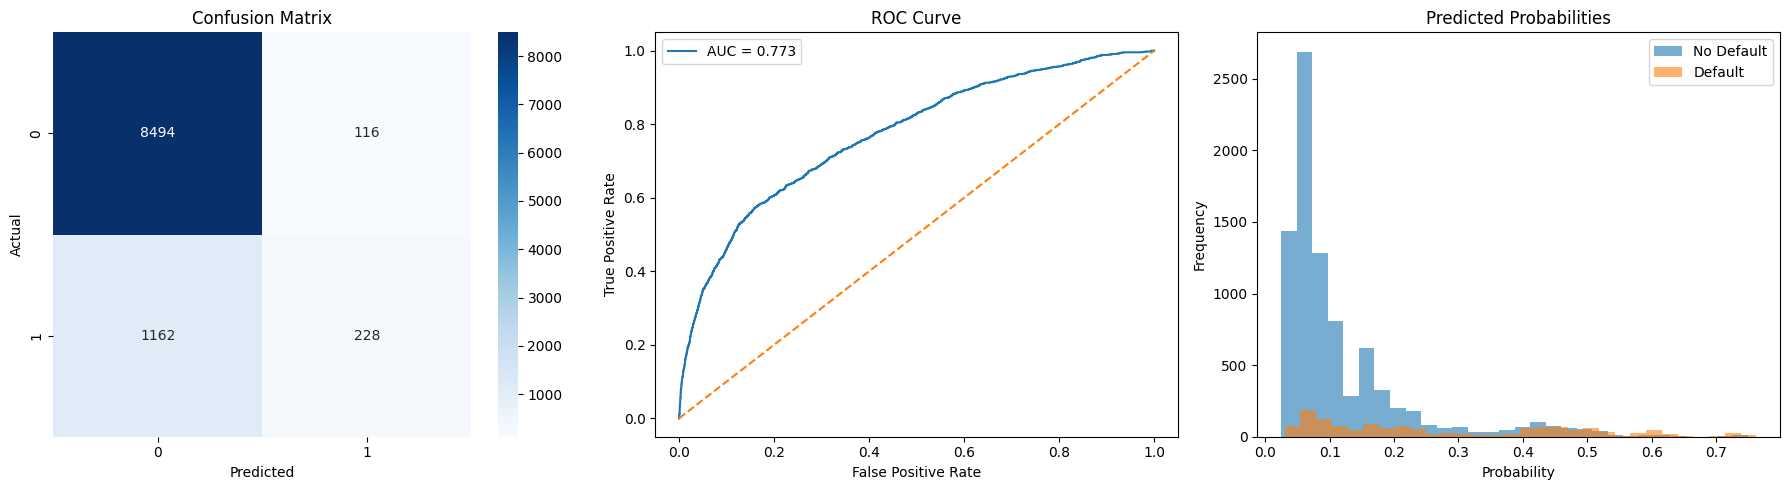

In [20]:
metrics.evaluate_model(
    y_test,
    y_pred_log,
    y_prob_log,
    "Régression Logistique"
)